# **4.4.1 A Simple Example**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1HuOv1ALZCKYVY-8JvOMgvCoxuZChIhhe?usp=sharing)


Branch-and-bound algorithms are widely considered to be the most effective methods for solving medium-sized general integer programming problems. These algorithms make no assumptions about the structure of a problem except that the objective function and the constraints must be linear. Even these restrictions can be relaxed without changing the basic framework of the technique.

&nbsp;&nbsp;&nbsp;&nbsp;In its simplest form, **branch-and-bound** is just an organized way of taking a hard problem and splitting it into two or more smaller and hence easier subproblems. If these subproblems are still too hard, we *branch* again and further subdivide the problems. The process is repeated until each of the subproblems can be easily solved. Branching is done in such a way that solving each of the subproblems and selecting the best answer found is equivalent to solving the original problem.

&nbsp;&nbsp;&nbsp;&nbsp;Consider the following simple example in two variables. A manufacturer has 300 person-hours available this week and 1,800 units of raw material. These resources can be used to build two products, A and B. The requirements and the profit for each item are given as follows:

<br>

<div align="center">

<table style="font-size:18px; border-collapse:collapse; text-align:center;">
  <tr>
    <th style="padding:8px 18px; border-bottom:2px solid black;">Product</th>
    <th style="padding:8px 18px; border-bottom:2px solid black;">Person-Hours</th>
    <th style="padding:8px 18px; border-bottom:2px solid black;">Raw Material</th>
    <th style="padding:8px 18px; border-bottom:2px solid black;">Profit ($)</th>
  </tr>
  <tr>
    <td style="padding:8px 18px;">A</td>
    <td style="padding:8px 18px;">150</td>
    <td style="padding:8px 18px;">300</td>
    <td style="padding:8px 18px;">600</td>
  </tr>
  <tr>
    <td style="padding:8px 18px; border-bottom:2px solid black;">B</td>
    <td style="padding:8px 18px; border-bottom:2px solid black;">10</td>
    <td style="padding:8px 18px; border-bottom:2px solid black;">400</td>
    <td style="padding:8px 18px; border-bottom:2px solid black;">100</td>
  </tr>
</table>

</div>

<br>

Let $x_1$ and $x_2$ represent the *integer* number of units of products A and B, respectively. We can formulate this problem as an integer linear programming problem:

$$
\begin{aligned}
\text{maximize} \qquad & z = 600x_1 + 100x_2 \\[6pt]
\text{subject to} \qquad & 150x_1 + 10x_2 \leq 300 \\
& 300x_1 + 400x_2 \leq 1800 \\
& x_1, x_2 \geq 0 \text{ and integer}
\end{aligned}
$$

<br>

This problem is illustrated in **Figure 4.1**. The feasible region is given by the discrete set of integer points within the constraint region. The optimal LP solution occurs at $x_1 = 1.789$ and $x_2 = 3.158$ with a profit of $z = 1389.47$. Unfortunately, we cannot sell a fractional number of items. One obvious alternative is to round down both values to $x_1 = 1$ and $x_2 = 3$, for a profit of $900$. We will call the feasible integer solution $x^I = (1, 3)$ the **current incumbent solution**, which is the best answer found thus far. When we find a better integer solution, we will update the current incumbent. Before reading any further, try to locate the optimal integer solution to the problem in **Figure 4.1**, and consider how integer solutions might be found in general.

The basic branch-and-bound algorithm results from the following observations:

- The feasible integer solution $x = (1, 3)$ with $z = 900$ was fairly easy to find. The optimal integer solution cannot have a lower value of $z$ than $900$. Thus, we write $z^I = 900$ and call this a *lower bound* on the optimal solution. Each time we find a higher valued integer solution, we replace the lower bound $z^I$. This is the *bound* part of branch-and-bound methods.

- Over the whole feasible region, the largest possible value of $z = 1389.47$, which is the real valued solution obtained from the LP. We call this an upper bound on the optimal integer function value.

- The graphical solution shows that $x_2 = 3.158$. This is infeasible because it is a fractional solution. Since $x_2$ must be an integer, then clearly either $x_2 \leq 3$ or $x_2 \geq 4$. This is equivalent to saying that $x_2$ cannot lie part way between 3 and 4.

Consider the following two subproblems:

$$
\begin{array}{rll}
[A] & \text{maximize} & z = 600x_1 + 100x_2 \\
& \text{subject to} & 150x_1 + 10x_2 \leq 300 \\
& & 300x_1 + 400x_2 \leq 1800 \\
& & x_1 \geq 0 \text{ and integer} \\
& & x_2 \geq 4 \text{ and integer}
\end{array}
$$

$$
\begin{array}{rll}
[B] & \text{maximize} & z = 600x_1 + 100x_2 \\
& \text{subject to} & 150x_1 + 10x_2 \leq 300 \\
& & 300x_1 + 400x_2 \leq 1800 \\
& & x_1, x_2 \geq 0 \text{ and integer} \\
& & x_2 \leq 3
\end{array}
$$

&nbsp;&nbsp;&nbsp;&nbsp;Observe that if we find the best integer solution of both of these subproblems, then one of them must be the optimal solution to the original problem. These subproblems are represented graphically in **Figure 4.2**, where the diagram is identical to **Figure 4.1** except that the range of values for $x_2$ between 3 and 4 is now infeasible. We say that we have **separated** on variable $x_2$.

&nbsp;&nbsp;&nbsp;&nbsp;Consider problem [A] first. The LP solution occurs at $x = (0.667, 4)$ with an objective function value of $z = 800$. Notice that $x_2$ is now integer valued. We will see that each time we separate, the chosen variable will always be integer, although it does not necessarily stay integer on subsequent iterations.

&nbsp;&nbsp;&nbsp;&nbsp;By definition, the linear programming solution is the largest value possible for the problem. Therefore, the value $z = 800$ is an upper bound on all possible solutions in the feasible region for problem [A]. Any integer solution to [A] must be $\leq 800$. However, we already have a feasible integer solution with $z^I = 900$. Therefore, problem [A] can be ignored as it cannot contain any answer better than 900. In branch-and-bound terminology, we say that problem [A] has been *fathomed*.

&nbsp;&nbsp;&nbsp;&nbsp;In general, a subproblem is called **fathomed** whenever it is no longer necessary to branch any further. A subproblem is fathomed when the LP solution is less than the current lower bound for a maximization problem, when the LP solution is infeasible, or when the LP produces an integer solution.

<div align="center">

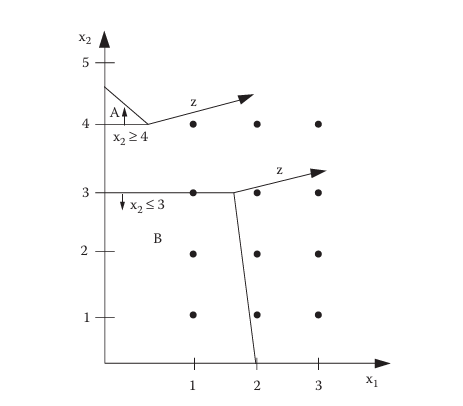

</div>

**Figure 4.2**  
Separate into two subproblems.

<br>

&nbsp;&nbsp;&nbsp;&nbsp;Problem [B] has its optimal LP solution at $x = (1.8, 3)$ with a function value of $z = 1,380$. This value gives us a new upper bound on the optimal integer solution. At each iteration of the branch-and-bound process, the upper and lower bounds can be revised until they eventually converge to the optimal solution. We now know that the optimal value lies between 900 and 1,380. Variable $x_2$ is integer valued, but $x_1$ is still fractional. We can now further divide problem [B] into two subproblems based on the fact that $x_1 \leq 1$ or $x_1 \geq 2$, as follows:

$$
\begin{array}{rll}
[B1] & \text{maximize} & z = 600x_1 + 100x_2 \\
& \text{subject to} & 150x_1 + 10x_2 \leq 300 \\
& & 300x_1 + 400x_2 \leq 1800 \\
& & x_1, x_2 \geq 0 \text{ and integer} \\
& & x_1 \leq 1 \\
& & x_2 \leq 3
\end{array}
$$

$$
\begin{array}{rll}
[B2] & \text{maximize} & z = 600x_1 + 100x_2 \\
& \text{subject to} & 150x_1 + 10x_2 \leq 300 \\
& & 300x_1 + 400x_2 \leq 1800 \\
& & x_2 \geq 0 \text{ and integer} \\
& & x_1 \geq 2 \text{ and integer} \\
& & x_2 \leq 3
\end{array}
$$

<br>

For problem [B1], it is easy to see that the optimal LP solution occurs at point $x = (1, 3)$ with a function value $z = 900$. Since $x$ is now integer valued, it must be optimal for this subproblem. This subproblem is considered to be fathomed because it gives us an integer solution: there is no need for further branching as the solution cannot get any better below this node. It is also considered fathomed because the solution of 900 is no better than the one we already obtained earlier. In either case, problem [B1] is finished.

&nbsp;&nbsp;&nbsp;&nbsp;Problem [B2] consists of the single point $x = (2, 0)$ with a function value of $z = 1,200$. This solution is both integer, and better than the previous lower bound. Since $x$ is integer, subproblem [B2] is fathomed and no further branching is required. Our new lower bound increases to $z^I = 1,200$ and $x^I = (2, 0)$ becomes the new current incumbent.

&nbsp;&nbsp;&nbsp;&nbsp;At this point, we observe that all of our subproblems have been fathomed. Therefore, $x^I = (2, 0)$ is the optimal integer solution, and $z^I = \$1,200$ is the optimal function value.

&nbsp;&nbsp;&nbsp;&nbsp;It is often convenient to display this procedure in the form of a **branch-and-bound tree**. The tree corresponding to the previous example is illustrated in **Figure 4.3**. Each subproblem is represented by a node in the tree. Each node must either be fathomed or split into subproblems, which are shown by lower level nodes.

&nbsp;&nbsp;&nbsp;&nbsp;In **Figure 4.3a**, node 0 represents the original problem. We construct nodes 1 and 2, for subproblems [A] and [B], respectively, by constraining $x_2$ in **Figure 4.3b**. Node 1 is fathomed and node 2 is further subdivided into nodes 3 and 4 in **Figure 4.3c**, corresponding to problems [B1] and [B2].

<br>




<div align="center">


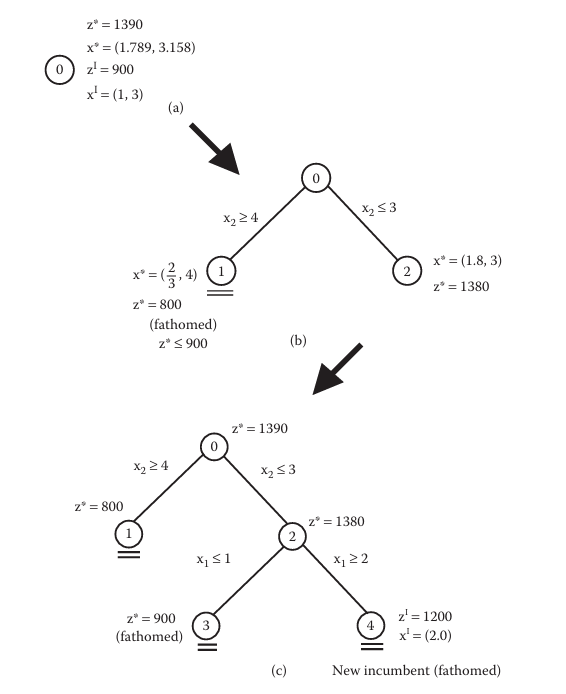


</div>


<br>

**Figure 4.3**  
Branch-and-bound example: (a) node 0: original problem, (b) subproblems [A] and [B], and (c) subproblems [B1] and [B2].

In [1]:
# ========================================
# 4.4.1 Branch-and-Bound — Simple Example
# LP Relaxation + Integer Solution + B&B Tree
# ========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import linprog, milp, LinearConstraint, Bounds

print('Libraries loaded successfully.')


Libraries loaded successfully.


In [2]:
# ========================================
# Book Example (Section 4.4.1)
# maximize z = 600x1 + 100x2
# s.t.  150x1 + 10x2  <= 300
#       300x1 + 400x2 <= 1800
#       x1, x2 >= 0, integer
# Textbook answer: x1=2, x2=0, z=1200
# ========================================

# Objective coefficients (negate for minimisation in scipy)
c = np.array([600., 100.])

# Constraint matrix and RHS
A = np.array([[150., 10.],
              [300., 400.]])
b = np.array([300., 1800.])

print('Problem data loaded.')
display(pd.DataFrame(A, columns=['x1 coeff','x2 coeff'],
                     index=['Person-hours constraint','Raw material constraint']))
print(f'RHS: {b}')
print(f'Objective: max {c[0]}x1 + {c[1]}x2')


Problem data loaded.


,x1 coeff,x2 coeff
Person-hours constraint,150.0,10.0
Raw material constraint,300.0,400.0


RHS: [ 300. 1800.]
Objective: max 600.0x1 + 100.0x2


In [3]:
# ========================================
# Algebraic Method: Manual Branch-and-Bound
# Shows each node's LP relaxation step-by-step,
# mirroring the textbook walkthrough.
# ========================================

def solve_lp(extra_bounds=None):
    """
    Solve the LP relaxation with optional extra bounds on variables.
    extra_bounds: list of (var_idx, 'lb'|'ub', value)
    Returns (z, x) or (None, None) if infeasible.
    """
    lb = [0., 0.]
    ub = [np.inf, np.inf]
    if extra_bounds:
        for idx, kind, val in extra_bounds:
            if kind == 'ub': ub[idx] = val
            else:            lb[idx] = val
    res = linprog(-c, A_ub=A, b_ub=b,
                  bounds=list(zip(lb, ub)), method='highs')
    if res.status != 0:
        return None, None
    return -res.fun, res.x

print('=== Manual Branch-and-Bound ===')
print()

# Node 0 — original LP
z0, x0 = solve_lp()
print(f'Node 0 (LP relaxation):')
print(f'  x = ({x0[0]:.4f}, {x0[1]:.4f}),  z* = {z0:.4f}  (upper bound)')
print(f'  x2 = {x0[1]:.3f} is fractional → branch on x2')
print()

# Node A — x2 >= 4
zA, xA = solve_lp([(1,'lb',4)])
print(f'Node A  (x2 >= 4):')
if zA is None:
    print('  Infeasible → fathomed')
else:
    print(f'  x = ({xA[0]:.4f}, {xA[1]:.4f}),  z* = {zA:.4f}')
    print(f'  z* = {zA:.1f} < current best (900) → fathomed')
print()

# Node B — x2 <= 3
zB, xB = solve_lp([(1,'ub',3)])
print(f'Node B  (x2 <= 3):')
print(f'  x = ({xB[0]:.4f}, {xB[1]:.4f}),  z* = {zB:.4f}')
print(f'  x1 = {xB[0]:.3f} is fractional → branch on x1')
print()

# Node B1 — x2 <= 3, x1 <= 1
zB1, xB1 = solve_lp([(1,'ub',3),(0,'ub',1)])
print(f'Node B1 (x2<=3, x1<=1):')
print(f'  x = ({xB1[0]:.4f}, {xB1[1]:.4f}),  z* = {zB1:.4f}')
print(f'  Integer solution → fathomed  (z={int(round(zB1))})')
print()

# Node B2 — x2 <= 3, x1 >= 2
zB2, xB2 = solve_lp([(1,'ub',3),(0,'lb',2)])
print(f'Node B2 (x2<=3, x1>=2):')
print(f'  x = ({xB2[0]:.4f}, {xB2[1]:.4f}),  z* = {zB2:.4f}')
print(f'  Integer solution → NEW INCUMBENT  z={int(round(zB2))}')
print()
print(f'All nodes fathomed.')
print(f'Optimal integer solution: x1={int(round(xB2[0]))}, x2={int(round(xB2[1]))}, z={int(round(zB2))}')
print(f'Textbook answer: x1=2, x2=0, z=1200  {chr(10004) if int(round(zB2))==1200 else chr(10008)}')


=== Manual Branch-and-Bound ===

Node 0 (LP relaxation):
  x = (1.7895, 3.1579),  z* = 1389.4737  (upper bound)
  x2 = 3.158 is fractional → branch on x2

Node A  (x2 >= 4):
  x = (0.6667, 4.0000),  z* = 800.0000
  z* = 800.0 < current best (900) → fathomed

Node B  (x2 <= 3):
  x = (1.8000, 3.0000),  z* = 1380.0000
  x1 = 1.800 is fractional → branch on x1

Node B1 (x2<=3, x1<=1):
  x = (1.0000, 3.0000),  z* = 900.0000
  Integer solution → fathomed  (z=900)

Node B2 (x2<=3, x1>=2):
  x = (2.0000, -0.0000),  z* = 1200.0000
  Integer solution → NEW INCUMBENT  z=1200

All nodes fathomed.
Optimal integer solution: x1=2, x2=0, z=1200
Textbook answer: x1=2, x2=0, z=1200  ✔


In [4]:
# ========================================
# Ready Function: scipy.optimize.milp
# One call solves the MIP directly.
# ========================================

# scipy.milp minimises, so negate the objective
res_lp = linprog(-c, A_ub=A, b_ub=b, method='highs')
z_lp   = -res_lp.fun

constraints  = LinearConstraint(A, -np.inf, b)
integrality  = np.array([1, 1])          # 1 = integer variable
bounds       = Bounds(lb=[0, 0], ub=[np.inf, np.inf])
res_ip = milp(-c, constraints=constraints,
              integrality=integrality, bounds=bounds)
z_ip   = -res_ip.fun
x_ip   = res_ip.x

print('=== LP Relaxation (node 0 upper bound) ===')
print(f'  x1 = {res_lp.x[0]:.4f},  x2 = {res_lp.x[1]:.4f}')
print(f'  z* = {z_lp:.4f}')
print()
print('=== scipy.milp — Integer Solution ===')
print(f'  x1 = {int(round(x_ip[0]))},  x2 = {int(round(x_ip[1]))}')
print(f'  z  = {int(round(z_ip))}')
print(f'Textbook answer: x1=2, x2=0, z=1200  {chr(10004) if int(round(z_ip))==1200 else chr(10008)}')


=== LP Relaxation (node 0 upper bound) ===
  x1 = 1.7895,  x2 = 3.1579
  z* = 1389.4737

=== scipy.milp — Integer Solution ===
  x1 = 2,  x2 = 0
  z  = 1200
Textbook answer: x1=2, x2=0, z=1200  ✔


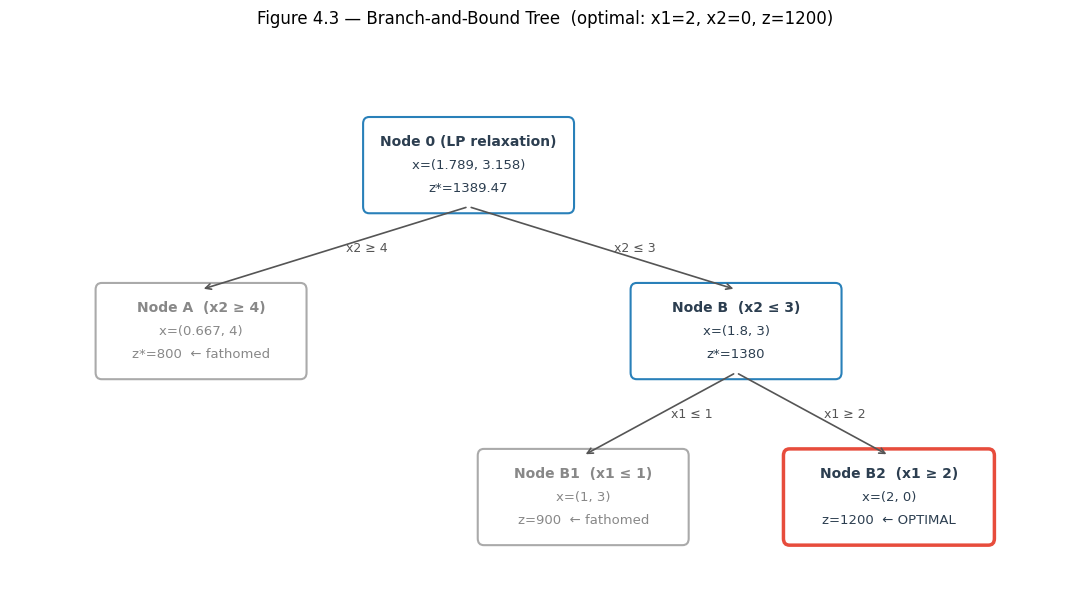

In [5]:
# ========================================
# Draw the Branch-and-Bound Tree
# Mirrors Figure 4.3 in the textbook
# ========================================

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

def draw_node(ax, x, y, lines, color='#2980b9', fathomed=False, incumbent=False):
    w, h = 2.6, 1.0
    ec = '#e74c3c' if incumbent else ('#aaaaaa' if fathomed else color)
    lw = 2.5 if incumbent else 1.5
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                    boxstyle='round,pad=0.08',
                                    facecolor='white', edgecolor=ec,
                                    linewidth=lw, zorder=3)
    ax.add_patch(rect)
    for i, line in enumerate(lines):
        fs = 9.5 if i > 0 else 10
        fw = 'bold' if i == 0 else 'normal'
        col = '#2c3e50' if not fathomed else '#888888'
        ax.text(x, y + 0.28 - i*0.28, line,
                ha='center', va='center', fontsize=fs,
                fontweight=fw, color=col, zorder=4)

def arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2+0.5), xytext=(x1, y1-0.5),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))
    mx, my = (x1+x2)/2, (y1+y2)/2
    if label:
        ax.text(mx+0.15, my, label, fontsize=9,
                color='#555555', ha='left', va='center')

# Nodes
draw_node(ax,  0,  4,
          ['Node 0 (LP relaxation)',
           'x=(1.789, 3.158)', 'z*=1389.47'])

draw_node(ax, -3.5, 2,
          ['Node A  (x2 ≥ 4)',
           'x=(0.667, 4)', 'z*=800  ← fathomed'],
          fathomed=True)

draw_node(ax,  3.5, 2,
          ['Node B  (x2 ≤ 3)',
           'x=(1.8, 3)', 'z*=1380'])

draw_node(ax,  1.5, 0,
          ['Node B1  (x1 ≤ 1)',
           'x=(1, 3)', 'z=900  ← fathomed'],
          fathomed=True)

draw_node(ax,  5.5, 0,
          ['Node B2  (x1 ≥ 2)',
           'x=(2, 0)', 'z=1200  ← OPTIMAL'],
          incumbent=True)

# Arrows
arrow(ax,  0, 4, -3.5, 2, 'x2 ≥ 4')
arrow(ax,  0, 4,  3.5, 2, 'x2 ≤ 3')
arrow(ax,  3.5, 2, 1.5, 0, 'x1 ≤ 1')
arrow(ax,  3.5, 2, 5.5, 0, 'x1 ≥ 2')

ax.set_xlim(-6, 8)
ax.set_ylim(-1, 5.5)
ax.set_title('Figure 4.3 — Branch-and-Bound Tree  (optimal: x1=2, x2=0, z=1200)',
             fontsize=12, pad=12)
plt.tight_layout()
plt.show()


In [6]:
# ========================================
# Your Own Integer Programming Problem
# Edit below, then run.
# ========================================

# Step 1: Define the problem
# Objective: maximize c @ x
custom_c = np.array([600., 100.])          # profit coefficients

# Constraints: A_custom @ x <= b_custom
custom_A = np.array([[150., 10.],
                     [300., 400.]])
custom_b = np.array([300., 1800.])

# Variable types: 1 = integer, 0 = continuous
custom_integrality = np.array([1, 1])

# Step 2: Solve
custom_constraints = LinearConstraint(custom_A, -np.inf, custom_b)
custom_bounds      = Bounds(lb=np.zeros(len(custom_c)),
                            ub=np.full(len(custom_c), np.inf))
res = milp(-custom_c,
           constraints=custom_constraints,
           integrality=custom_integrality,
           bounds=custom_bounds)

# Step 3: Print result
print('=== Integer Programming Solution ===')
for i, xi in enumerate(res.x):
    print(f'  x{i+1} = {int(round(xi))}')
print(f'  z  = {int(round(-res.fun))}')


=== Integer Programming Solution ===
  x1 = 2
  x2 = 0
  z  = 1200
